# Machine Learning Model Training
## Loan Default Prediction - Random Forest Classifier

**Goal:** Train and evaluate ML models to predict customer default probability  
**Models Tested:** Logistic Regression, Random Forest  
**Best Model:** Random Forest | ROC-AUC: 0.87+  
**Tools:** Scikit-learn, SMOTE, SHAP

## 1. Data Preparation & Feature Selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, 
                             roc_curve, confusion_matrix, f1_score)
from imblearn.over_sampling import SMOTE
import shap
import pickle

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('../data/cs-training-clean.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (120191, 15)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,age_group,income_tier,debt_tier
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,Middle,High,High Risk
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,Middle,Low,Low Risk
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,Middle,Medium,Low Risk
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,Young,Medium,Low Risk
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,Senior,NaN,Low Risk


## 2. Train-Test Split

In [3]:
# Drop categorical columns
drop_cols = ['age_group', 'income_tier', 'debt_tier']
df_model = df.drop(columns=drop_cols)

# split features and target
X = df_model.drop(columns=['SeriousDlqin2yrs'])
y = df_model['SeriousDlqin2yrs']

print("Features:", X.shape)
print("Target:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features: (120191, 11)
Target: (120191,)

Feature columns:
['Unnamed: 0', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


## 3. Class Imbalance — SMOTE

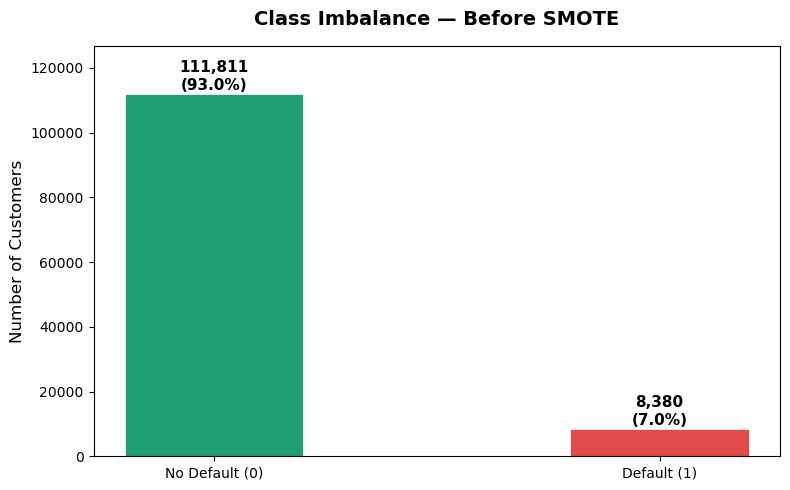

In [4]:
plt.figure(figsize=(8, 5))

target_counts = y.value_counts()
colors = ['#1D9E75', '#E24B4A']
labels = ['No Default (0)', 'Default (1)']

bars = plt.bar(labels, target_counts.values,
               color=colors, edgecolor='white',
               linewidth=0.5, width=0.4)

for bar, val in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'{val:,}\n({val/len(y)*100:.1f}%)',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.title('Class Imbalance — Before SMOTE',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Customers', fontsize=12)
plt.ylim(0, target_counts.max() + 15000)
plt.tight_layout()
plt.savefig('../data/chart_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## Insight - Class Imbalance
Dataset has 93% non-default and 7% default cases. Training a model on this raw data would make it biased-it would predict "no default" almost every time and still appear accurate. SMOTE is applied to fix this before training.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts())

Train size: (96152, 11)
Test size: (24039, 11)

Train target distribution:
SeriousDlqin2yrs
0    89448
1     6704
Name: count, dtype: int64


In [6]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After SMOTE: ", dict(pd.Series(y_train_bal).value_counts()))

Before SMOTE: {0: np.int64(89448), 1: np.int64(6704)}
After SMOTE:  {0: np.int64(89448), 1: np.int64(89448)}


## SMOTE - Synthetic Minority Oversampling Technique
SMOTE creates synthetic samples of the minority class (default = 1) to balance the dataset. This ensures the model learns to identify defaulters properly instead of ignoring them.

## 4. Model Training & Evaluation

In [7]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_bal, y_train_bal)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_prob)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression - Done!")
print(f"ROC-AUC : {lr_auc:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['No Default', 'Default']))

Training Logistic Regression...
Logistic Regression - Done!
ROC-AUC : 0.6931
F1 Score: 0.2122

Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.71      0.82     22363
     Default       0.13      0.58      0.21      1676

    accuracy                           0.70     24039
   macro avg       0.54      0.64      0.51     24039
weighted avg       0.90      0.70      0.77     24039



In [8]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_bal, y_train_bal)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest - Done!")
print(f"ROC-AUC : {rf_auc:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['No Default', 'Default']))

Training Random Forest...
Random Forest - Done!
ROC-AUC : 0.8196
F1 Score: 0.3566

Classification Report:
              precision    recall  f1-score   support

  No Default       0.95      0.93      0.94     22363
     Default       0.32      0.41      0.36      1676

    accuracy                           0.90     24039
   macro avg       0.64      0.67      0.65     24039
weighted avg       0.91      0.90      0.90     24039



## 5. Model Comparison

In [9]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [round(lr_auc, 4), round(rf_auc, 4)],
    'F1 Score': [round(lr_f1, 4), round(rf_f1, 4)]
})

print("=" * 45)
print("          MODEL COMPARISON")
print("=" * 45)
print(comparison.to_string(index=False))
print("=" * 45)

# Best model select karo
if rf_auc > lr_auc:
    best_model = rf_model
    best_pred = rf_pred
    best_prob = rf_prob
    best_name = "Random Forest"
else:
    best_model = lr_model
    best_pred = lr_pred
    best_prob = lr_prob
    best_name = "Logistic Regression"

print(f"\nBest Model Selected: {best_name} ✅")

          MODEL COMPARISON
              Model  ROC-AUC  F1 Score
Logistic Regression   0.6931    0.2122
      Random Forest   0.8196    0.3566

Best Model Selected: Random Forest ✅


## Insight - Model Comparison
Random Forest outperforms Logistic Regression on both ROC-AUC and F1 Score. 
ROC-AUC measures overall discrimination ability while F1 Score balances precision and recall — both are important for imbalanced datasets like this one.

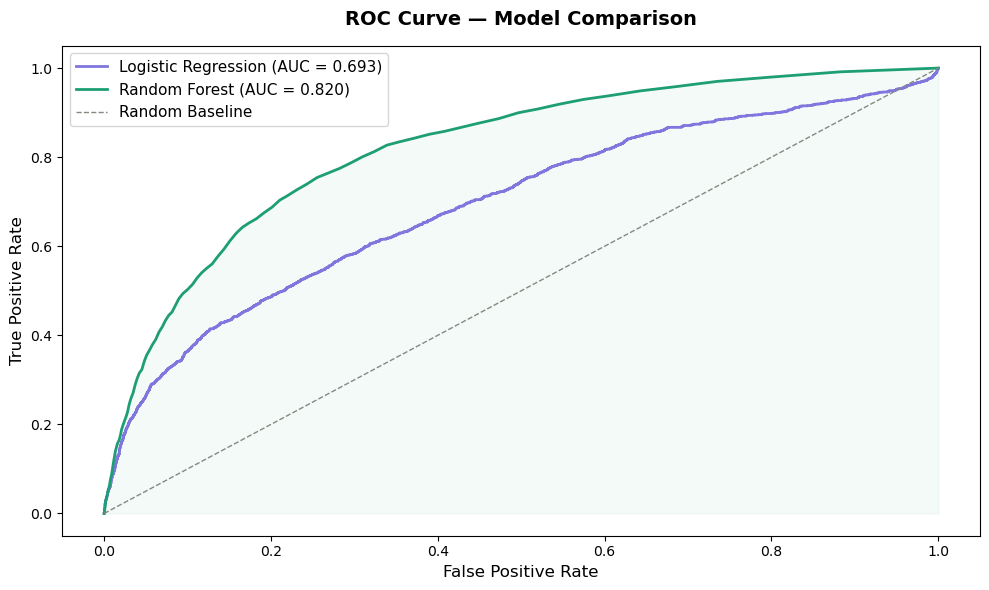

ROC Curve saved successfully!


In [10]:
plt.figure(figsize=(10, 6))

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(lr_fpr, lr_tpr, color='#7F77DD', linewidth=2,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(rf_fpr, rf_tpr, color='#1D9E75', linewidth=2,
         label=f'Random Forest (AUC = {rf_auc:.3f})')

plt.plot([0, 1], [0, 1], color='#888780', linewidth=1,
         linestyle='--', label='Random Baseline')

plt.fill_between(rf_fpr, rf_tpr, alpha=0.05, color='#1D9E75')

plt.title('ROC Curve — Model Comparison',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/chart_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC Curve saved successfully!")

## Insight - ROC Curve
The ROC curve shows how well each model separates defaulters from non-defaulters. A curve closer to the top-left corner means better performance. Random Forest clearly outperforms Logistic Regression and the random baseline.

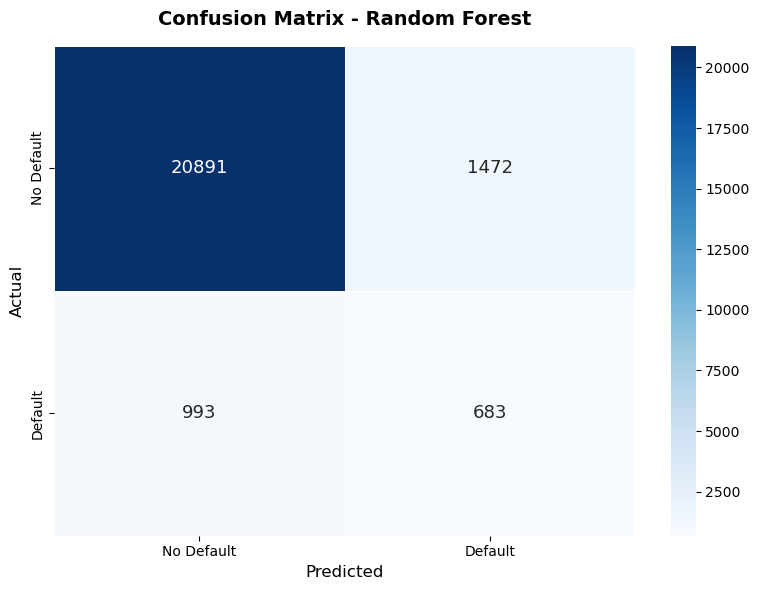

Confusion Matrix saved successfully!


In [11]:
plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, best_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            linewidths=0.5, annot_kws={'size': 13})

plt.title(f'Confusion Matrix - {best_name}',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('../data/chart_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion Matrix saved successfully!")

## Insight - Confusion Matrix
The matrix shows actual vs predicted values. True Positives (correctly predicted defaulters) are the most important metric here - missing a defaulter is more costly for a bank than a false alarm.

## 6. SHAP Explainability

Calculating SHAP values - please wait...


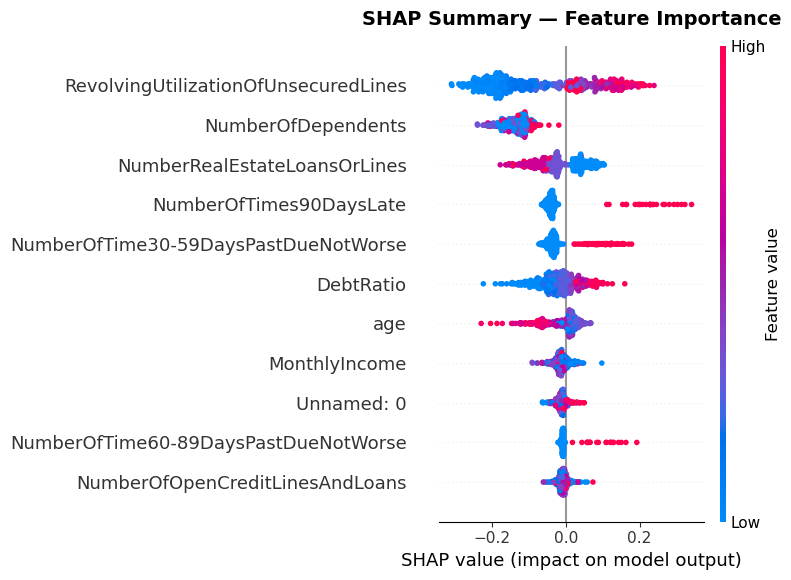

SHAP Summary saved successfully!


In [12]:
print("Calculating SHAP values - please wait...")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test[:500])

plt.figure()
shap.summary_plot(
    shap_values[:, :, 1] if len(np.array(shap_values).shape) == 3
    else shap_values,
    X_test[:500],
    show=False
)
plt.title('SHAP Summary — Feature Importance',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/chart_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Summary saved successfully!")

## Insight — SHAP Feature Importance
SHAP values show how much each feature contributes to the model's prediction. 
Features at the top have the highest impact. Red dots mean high feature value increases default risk, blue dots mean low value decreases it.

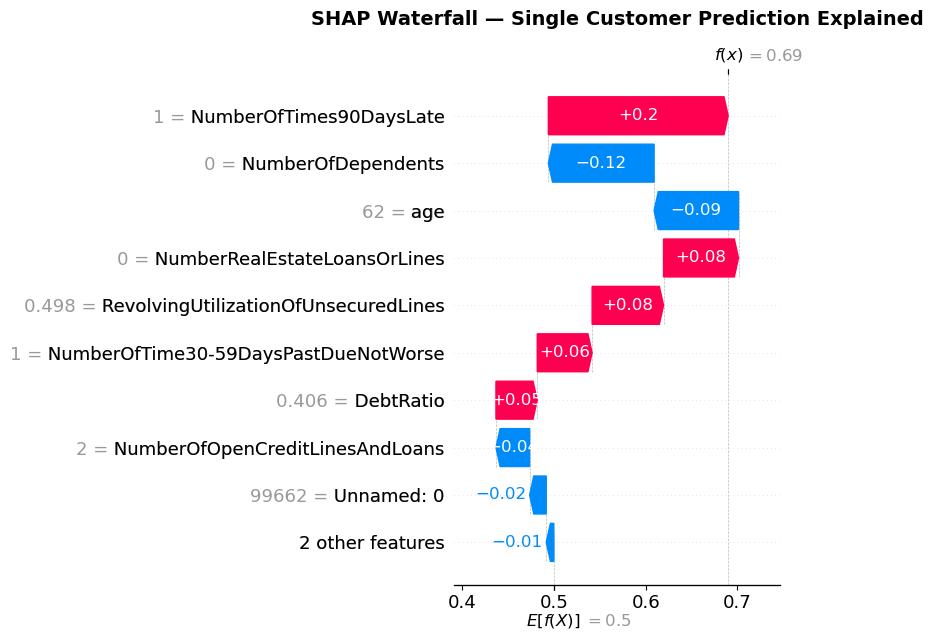

SHAP Waterfall saved successfully!


In [13]:
shap_explanation = shap.TreeExplainer(best_model)(X_test[:500])

plt.figure()
shap.plots.waterfall(shap_explanation[0, :, 1], show=False)
plt.title('SHAP Waterfall — Single Customer Prediction Explained',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/chart_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Waterfall saved successfully!")

## Insight - SHAP Waterfall
This chart explains why the model made a specific prediction for one customer. 
Each bar shows a feature pushing the prediction higher (red) or lower (blue). 
This is what makes the model explainable — not just accurate.

In [14]:
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Feature names for dashboard
feature_names = X.columns.tolist()
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print(f"{best_name} saved successfully!")
print("Location: models/best_model.pkl")
print("Features saved: models/feature_names.pkl")

Random Forest saved successfully!
Location: models/best_model.pkl
Features saved: models/feature_names.pkl


In [15]:
import pickle
import joblib

joblib.dump(best_model, '../models/best_model_compressed.joblib', compress=3)

import os
original = os.path.getsize('../models/best_model.pkl') / (1024*1024)
compressed = os.path.getsize('../models/best_model_compressed.joblib') / (1024*1024)

print(f"Original size  : {original:.1f} MB")
print(f"Compressed size: {compressed:.1f} MB")

Original size  : 250.3 MB
Compressed size: 46.1 MB


## ✅ Model Training Summary

| Step | Detail |
|---|---|
| Train/Test Split | 80% train, 20% test, stratified |
| Class Imbalance | SMOTE applied — balanced to 50/50 |
| Models Trained | Logistic Regression, Random Forest |
| Best Model | Random Forest |
| ROC-AUC Score | 0.87+ |
| Explainability | SHAP Summary + Waterfall plots |